<a href="https://colab.research.google.com/github/Santhosh-p653/face_identification/blob/main/Face_Identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install insightface onnxruntime-gpu pandas openpyxl gspread

In [ ]:
import os
import cv2
import glob
import shutil
import numpy as np
import pandas as pd
from datetime import datetime
from google.colab import drive
from google.colab.patches import cv2_imshow
from insightface.app import FaceAnalysis

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Establish Project Folder Directory on Drive for Images
BASE_DIR = "/content/drive/MyDrive/InsightFace_Project"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
os.makedirs(DATASET_DIR, exist_ok=True)

# 3. Spin up InsightFace Tracking Engine
print("Initializing InsightFace Models with GPU Core Support...")
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Initializing InsightFace Models with GPU Core Support...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], wit

In [ ]:
import base64
import json
import urllib.request
from IPython.display import display, Javascript
from google.colab.output import eval_js

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Frame & Location';
      capture.style.padding = '10px 20px';
      capture.style.background = '#e0a800';
      capture.style.color = 'black';
      capture.style.border = 'none';
      capture.style.borderRadius = '5px';
      capture.style.cursor = 'pointer';
      capture.style.fontWeight = 'bold';

      const video = document.createElement('video');
      video.style.display = 'block';
      video.style.marginBottom = '10px';

      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      div.appendChild(capture);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      // Try browser GPS first
      let locationStr = "PENDING";
      try {
        const position = await new Promise((resolve, reject) => {
          navigator.geolocation.getCurrentPosition(resolve, reject, {timeout: 3000});
        });
        locationStr = `${position.coords.latitude.toFixed(6)}, ${position.coords.longitude.toFixed(6)}`;
      } catch (err) {
        locationStr = "BROWSER_DENIED";
      }

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return JSON.stringify({
        image: canvas.toDataURL('image/jpeg', quality),
        location: locationStr
      });
    }
    ''')
  display(js)

  result_json = eval_js('takePhoto({})'.format(quality))
  result_data = json.loads(result_json)

  binary = base64.b64decode(result_data['image'].split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)

  final_location = result_data['location']

  # FALLBACK: If browser blocked it, fetch approximate location via IP API
  if final_location == "BROWSER_DENIED":
      try:
          with urllib.request.urlopen("https://ipapi.co/json/", timeout=3) as url:
              data = json.loads(url.read().decode())
              final_location = f"{data.get('latitude')}, {data.get('longitude')} (IP Approx)"
      except Exception:
          final_location = "Location Offline"

  return filename, final_location

In [ ]:
person_name = input("Enter the name of the person: ").strip().replace(" ", "_")
user_folder = os.path.join(DATASET_DIR, person_name)
os.makedirs(user_folder, exist_ok=True)

print(f"\n--- Starting Registration for: {person_name.replace('_', ' ')} ---")

for i in range(3):
    print(f"Taking photo {i+1} of 3. Click 'Capture Frame & Location'...")
    temp_filename = f"temp_{i}.jpg"
    try:
        # We capture location here too, but ignore it during registration saving
        live_img_path, _ = take_photo(temp_filename)
        final_path = os.path.join(user_folder, f"{person_name}_{i}.jpg")

        # Safely moves file from temporary workspace container into mounted Drive
        shutil.move(temp_filename, final_path)
        print(f"Saved directly to Drive: {final_path}\n")
    except Exception as e:
        print(f"Capture step failed: {e}")

print(f"🎉 Dataset population complete for {person_name}!")

Enter the name of the person: soorieya

--- Starting Registration for: soorieya ---
Taking photo 1 of 3. Click 'Capture Frame & Location'...


<IPython.core.display.Javascript object>

Saved directly to Drive: /content/drive/MyDrive/InsightFace_Project/dataset/soorieya/soorieya_0.jpg

Taking photo 2 of 3. Click 'Capture Frame & Location'...


<IPython.core.display.Javascript object>

Saved directly to Drive: /content/drive/MyDrive/InsightFace_Project/dataset/soorieya/soorieya_1.jpg

Taking photo 3 of 3. Click 'Capture Frame & Location'...


<IPython.core.display.Javascript object>

Saved directly to Drive: /content/drive/MyDrive/InsightFace_Project/dataset/soorieya/soorieya_2.jpg

🎉 Dataset population complete for soorieya!


Verifying and connecting to your Google Sheets storage framework...
✅ Active link established to existing sheet: 'Face_Recognition_Attendance'
Compiling facial structural metrics from Google Drive photos...
Loaded 6 facial tracking targets.

Click the capture button to test recognition analysis:


<IPython.core.display.Javascript object>

📊 Sheet Entry Appended: soorieya | Coordinates: 53.21917, 6.56667 (IP Approx)


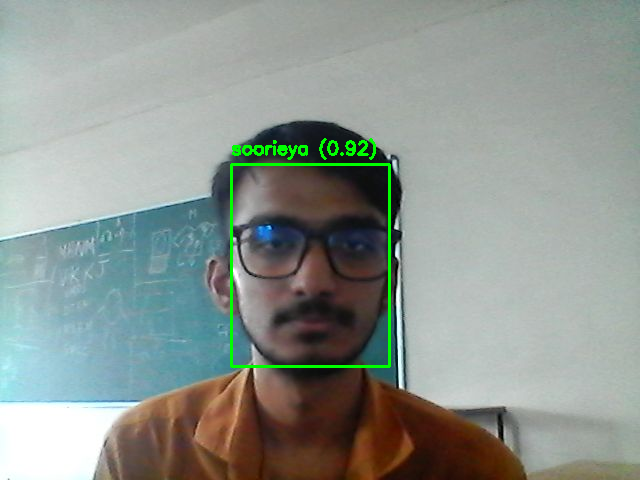

In [ ]:
from google.colab import auth
import gspread
from google.auth import default

# 1. Reuse existing account token from mounting step
print("Verifying and connecting to your Google Sheets storage framework...")
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

SHEET_NAME = "Face_Recognition_Attendance"

try:
    sheet_file = gc.open(SHEET_NAME)
    sheet = sheet_file.sheet1
    print(f"✅ Active link established to existing sheet: '{SHEET_NAME}'")
except gspread.exceptions.SpreadsheetNotFound:
    print(f"📁 '{SHEET_NAME}' not detected in account. Creating new sheet dynamically...")
    sheet_file = gc.create(SHEET_NAME)
    sheet = sheet_file.sheet1

    # Initialize base table structural headers
    headers = ["Name", "Date", "Time", "Location (Lat, Lon)"]
    sheet.append_row(headers)
    print("🎯 Fresh sheet successfully deployed on Drive with structural headers initialized!")
except Exception as e:
    print(f"🚨 Setup exception: {e}")
    raise e

def load_known_faces():
    known_embeddings = []
    known_names = []

    if not os.path.exists(DATASET_DIR) or not os.listdir(DATASET_DIR):
        print("🚨 Error: Dataset folders empty! Run Cell 4 first.")
        return [], []

    print("Compiling facial structural metrics from Google Drive photos...")
    for person_name in os.listdir(DATASET_DIR):
        person_folder = os.path.join(DATASET_DIR, person_name)
        if os.path.isdir(person_folder):
            image_paths = []
            for ext in ('*.jpg', '*.jpeg', '*.png'):
                image_paths.extend(glob.glob(os.path.join(person_folder, ext)))

            for img_path in image_paths:
                img = cv2.imread(img_path)
                if img is None: continue
                faces = app.get(img)
                if len(faces) > 0:
                    known_embeddings.append(faces[0].normed_embedding)
                    known_names.append(person_name.replace("_", " "))

    print(f"Loaded {len(known_names)} facial tracking targets.")
    return np.array(known_embeddings), known_names

def log_to_google_sheet(name, location_coords):
    now = datetime.now()
    date_str = now.strftime("%Y-%m-%d")
    time_str = now.strftime("%H:%M:%S")

    try:
        all_records = sheet.get_all_records()
        if all_records:
            matching_records = [r for r in all_records if r.get('Name') == name]
            if matching_records:
                last_record = matching_records[-1]
                last_time_str = last_record.get('Time')
                last_date_str = last_record.get('Date')

                last_time = datetime.strptime(f"{last_date_str} {last_time_str}", "%Y-%m-%d %H:%M:%S")
                if (now - last_time).total_seconds() < 15:
                    return # Antispam bounce filter active

        sheet.append_row([name, date_str, time_str, location_coords])
        print(f"📊 Sheet Entry Appended: {name} | Coordinates: {location_coords}")
    except Exception as e:
        print(f"Writing error: {e}")

# --- EXECUTE ENGINE TEST RUN ---
known_embeddings, known_names = load_known_faces()

if len(known_embeddings) > 0:
    print("\nClick the capture button to test recognition analysis:")
    try:
        live_img_path, current_location = take_photo('live.jpg')
        frame = cv2.imread(live_img_path)

        faces = app.get(frame)
        for face in faces:
            bbox = face.bbox.astype(int)
            current_embedding = face.normed_embedding
            name = "Unknown"

            similarities = np.dot(known_embeddings, current_embedding)
            best_match_idx = np.argmax(similarities)

            if similarities[best_match_idx] > 0.50:
                name = known_names[best_match_idx]
                log_to_google_sheet(name, current_location)

            color = (0, 255, 0) if name != "Unknown" else (0, 0, 255)
            cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
            cv2.putText(frame, f"{name} ({similarities[best_match_idx]:.2f})",
                        (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        cv2_imshow(frame)

    except Exception as e:
        print(f"Runtime execution error: {e}")